# Cat vs Dog Image Classification using Convolutional Neural Networks (CNN)

## Introduction

Image classification is one of the most popular applications of Deep Learning in Computer Vision. In this project, a Convolutional Neural Network (CNN) is developed to classify images into two categories: Cat and Dog. The images are preprocessed using image augmentation techniques, and the CNN model learns visual features such as edges, textures, and shapes to accurately distinguish between the two classes.

## Objective :

To build a Convolutional Neural Network (CNN) model that accurately classifies input images as either a cat or a dog using TensorFlow/Keras.

## 1. Import Required Libraries

In [1]:
# Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

## 2. Define Dataset Paths

In [2]:
# Dataset paths

train_path = r"C:\Users\shifa\Downloads\training_set\training_set"
test_path = r"C:\Users\shifa\Downloads\test_set\test_set"

## 3. Image Preprocessing

In [3]:
# Image Preprocessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

## 4. Load Training and Testing Images

In [4]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [5]:
test_path =  r"C:\Users\shifa\Downloads\test_set\test_set"

In [6]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary',
    shuffle=False
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


## 5. Build the CNN Model

In [7]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

C:\Users\shifa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Compile the Model

In [8]:
# Model Compilation

model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 7. Display Model Summary

In [9]:
# Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 6 : Early Stopping

es = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

## 8. Train the CNN Model

In [11]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 160s 625ms/step - accuracy: 0.5739 - loss: 0.7008 - val_accuracy: 0.6476 - val_loss: 0.6626
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 187s 566ms/step - accuracy: 0.6405 - loss: 0.6438 - val_accuracy: 0.6668 - val_loss: 0.6331
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 204s 575ms/step - accuracy: 0.6741 - loss: 0.6072 - val_accuracy: 0.7143 - val_loss: 0.5684
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 202s 574ms/step - accuracy: 0.6874 - loss: 0.5866 - val_accuracy: 0.7252 - val_loss: 0.5519
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 204s 580ms/step - accuracy: 0.7264 - loss: 0.5463 - val_accuracy: 0.7232 - val_loss: 0.5477
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 189s 529ms/step - accuracy: 0.7467 - loss: 0.5196 - val_accuracy: 0.7528 - val_loss: 0.5165
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.7600 - loss: 0.4992 - val_accuracy: 0.7746 - val_loss: 0.4943
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 177s 577ms/step - accuracy: 0.7821 -

## 9. Visualize Training Performance

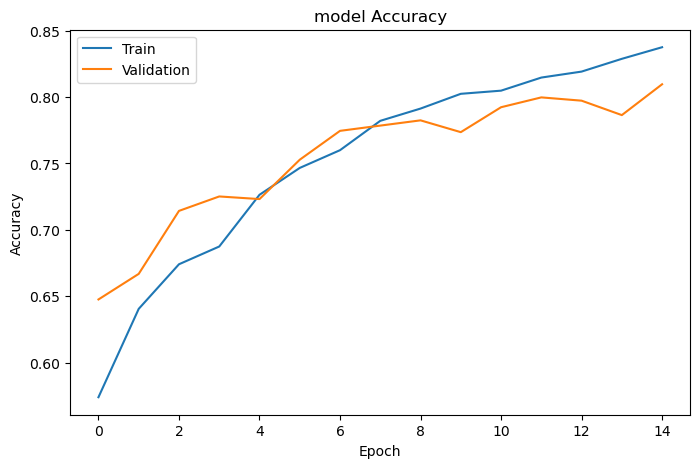

In [12]:
# Step 7 : Accuracy Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

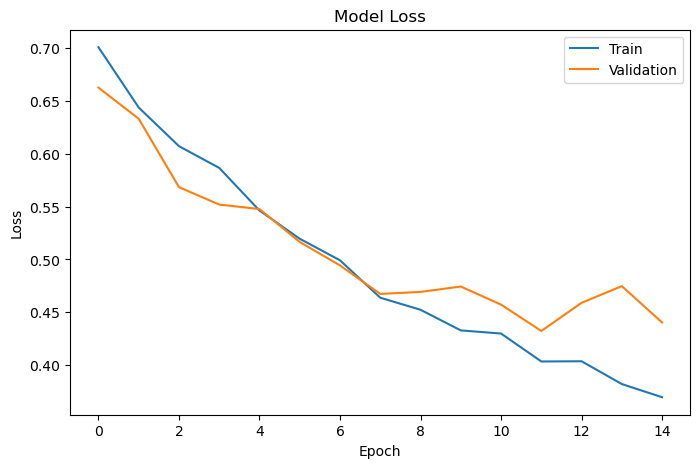

In [13]:
# Step 8 : Loss Graph

plt.figure(figsize= (8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

## 10. Evaluate the Model

In [14]:
# Step 9 : Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.7998 - loss: 0.4323
Accuracy 0.799802303314209
Loss 0.4323032796382904


### Confusion Matrix

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step


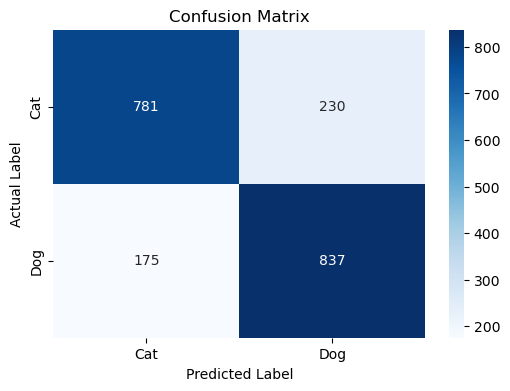

In [15]:
# Predict on test data
y_pred_prob = model.predict(test_data)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# True class labels
y_true = test_data.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 11. Save the Trained Model

In [16]:
# Step 10 : Save Model

model.save("cat_dog_cnn.h5")
print("Model saved successfully!")

Model saved successfully!


## 12. Load the Saved Model

In [17]:
# Step 11 : Load Model

model = load_model("cat_dog_cnn.h5")

## 13. Predict on a New Image

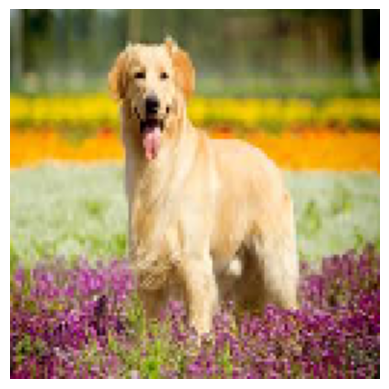

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Prediction Score : 0.95218855


In [18]:
# Step 12 : Predict New Image

img_path = r"C:\Users\shifa\Downloads\Dog_download.jpg"

img = image.load_img(
    img_path,
    target_size= (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis= 0)

pred = model.predict(img_arr)

print("Prediction Score :" , pred[0][0])

In [19]:
# Step 13 : Final Prediction

if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Dog


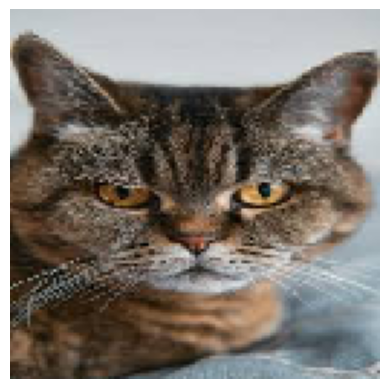

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Prediction Score: 0.023341311
Cat


In [22]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model ("cat_dog_cnn.h5")
img_path = r"C:\Users\shifa\Downloads\images_cat.jpg"

img = image.load_img(img_path, target_size = (128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis = 0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

## Conclusion

A Convolutional Neural Network (CNN) was successfully developed to classify images as cats or dogs. After preprocessing the dataset and training the model with TensorFlow/Keras, the model demonstrated effective learning and achieved reliable classification performance. The trained model was saved for future inference and deployment in real-world image classification applications.

## Streamlit Application Deployment

## Streamlit Application Development

In this phase, the trained CNN model is deployed using Streamlit. A user-friendly web application is created where users can upload an image, and the model predicts whether the uploaded image is a Cat or Dog.

## Streamlit App Features

The Streamlit application includes:
- Image upload option
- Image preprocessing
- Loading the saved CNN model
- Real-time Cat/Dog prediction
- Confidence score display
- Professional user interface

## Running the Streamlit Application

The application is run using the following command:

```bash
streamlit run catdog_app.py

## Streamlit Output

The final application allows the user to upload an image and displays the predicted class with confidence score.

## Final Conclusion

A CNN model was successfully developed to classify images as Cat or Dog. The model was trained, evaluated using accuracy, confusion matrix, and classification report, and tested with unseen images. Finally, the trained model was deployed using Streamlit, allowing real-time image prediction through a web application.